# MultiCycPermea ID/OD — Hard-sample analysis

**Goal.** For the val-best checkpoint of MultiCycPermea on each of the ID, OD (and Cliff_ratio for reference) splits, find which test samples the model fails on, and characterise them along three axes:

1. **Target-distribution position** — does the model fail on tails / outliers / specific value ranges of `PAMPA`?
2. **Molecular descriptors** — MolWt, LogP, TPSA, qed, ring/HBD/HBA counts, length, etc.
3. **Error patterns** — over- vs. under-prediction, train-set neighbourhood (Tanimoto), comparison ID vs. OD.

**Input.** Per-sample test predictions dumped by the patched `train.py` to
`MultiCycPermea/DL/pred_data/<RUN_NAME>/best_test_predictions.csv`. The model selected is the epoch minimising `val_MSE + (1 − val_R²)`.

In [1]:
from pathlib import Path
import glob, os, math, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ROOT  = Path('/ssd0/sohyun/cyclic_peptide/cyclic_peptide_permeability')
MCP   = ROOT / 'MultiCycPermea' / 'DL'
PRED  = MCP / 'pred_data'
DATA  = MCP / 'data' / 'ours'

# Pick the most recent dump for each split. Patched train.py writes:
#   pred_data/<RUN_NAME>/best_test_predictions.csv
# RUN_NAME is e.g. 'ours_ID_dump_20260527_110940'.
def latest_dump(prefix):
    hits = sorted((PRED).glob(f'{prefix}*/best_test_predictions.csv'))
    if not hits:
        raise FileNotFoundError(f'no dump for prefix={prefix} under {PRED}')
    return hits[-1]

DUMPS = {
    'ID':          latest_dump('ours_ID_dump_'),
    'OD':          latest_dump('ours_OD_dump_'),
    'Cliff_ratio': latest_dump('ours_Cliff_ratio_dump_'),
}
DUMPS

{'ID': PosixPath('/ssd0/sohyun/cyclic_peptide/cyclic_peptide_permeability/MultiCycPermea/DL/pred_data/ours_ID_dump_20260527_110940/best_test_predictions.csv'),
 'OD': PosixPath('/ssd0/sohyun/cyclic_peptide/cyclic_peptide_permeability/MultiCycPermea/DL/pred_data/ours_OD_dump_20260527_110940/best_test_predictions.csv'),
 'Cliff_ratio': PosixPath('/ssd0/sohyun/cyclic_peptide/cyclic_peptide_permeability/MultiCycPermea/DL/pred_data/ours_Cliff_ratio_dump_20260527_111201/best_test_predictions.csv')}

In [2]:
# Load predictions and join with the full test CSV (which carries descriptors)
DESC_COLS = [
    'SMILES','Sequence','Monomer_Length','Monomer_Length_in_Main_Chain',
    'Sequence_LogP','Sequence_TPSA',
    'MolWt','HeavyAtomMolWt','ExactMolWt','NumValenceElectrons',
    'qed','MaxPartialCharge','MinPartialCharge',
    'FpDensityMorgan1','FpDensityMorgan2','FpDensityMorgan3',
    'NumHDonors','NumHAcceptors','NumRotatableBonds','NumAromaticRings','RingCount',
    'TPSA','MolLogP','LabuteASA',
]

def load_split(split, pred_path):
    pred = pd.read_csv(pred_path)
    test = pd.read_csv(DATA / f'{split}_test.csv')
    keep = ['CycPeptMPDB_ID', 'PAMPA'] + [c for c in DESC_COLS if c in test.columns]
    df = pred.merge(test[keep], on='CycPeptMPDB_ID', how='left')
    df['residual']      = df['y_pred'] - df['y_true']
    df['abs_residual']  = df['residual'].abs()
    df['split']         = split
    return df

frames = {s: load_split(s, p) for s, p in DUMPS.items()}
for s, df in frames.items():
    print(f'{s:>12}: N={len(df):4d}  | y_true range [{df["y_true"].min():.2f}, {df["y_true"].max():.2f}] | '
          f'MAE={df["abs_residual"].mean():.4f}  RMSE={(df["residual"]**2).mean()**0.5:.4f}')
all_df = pd.concat(frames.values(), ignore_index=True)
all_df.head()

          ID: N= 491  | y_true range [-9.00, -4.00] | MAE=0.2735  RMSE=0.4155
          OD: N= 488  | y_true range [-8.00, -4.81] | MAE=0.3774  RMSE=0.5476
 Cliff_ratio: N= 493  | y_true range [-9.46, -4.00] | MAE=0.2840  RMSE=0.4388


,CycPeptMPDB_ID,y_true,y_pred,PAMPA,SMILES,Sequence,Monomer_Length,Monomer_Length_in_Main_Chain,Sequence_LogP,Sequence_TPSA,...,NumHAcceptors,NumRotatableBonds,NumAromaticRings,RingCount,TPSA,MolLogP,LabuteASA,residual,abs_residual,split
0,6271,-5.62,-5.569360,-5.62,CC(=O)N1CCC[C@H]1C(=O)N(C)[C@@H](CC(C)C)C(=O)N...,"['ac-', 'P', 'meL', 'T', 'L', 'Me_dL', 'meL', ...",10,7,"[0.2052, 0.2795, 1.1616, -0.1918, 0.8194, 1.16...","[17.07, 20.31, 20.31, 38.33, 29.1, 20.31, 20.3...",...,11,14,0,3,235.46,2.9464,434.636102,0.050640,0.050640,ID
1,6432,-5.85,-5.379865,-5.85,CC(=O)N1CCC[C@@H]1C(=O)N(C)[C@@H](CC(C)C)C(=O)...,"['ac-', 'dP', 'meL', 'T', 'dL', 'meL', 'meL', ...",10,7,"[0.2052, 0.2795, 1.1616, -0.1918, 0.8194, 1.16...","[17.07, 20.31, 20.31, 38.33, 29.1, 20.31, 20.3...",...,11,14,0,3,235.46,2.9464,434.636102,0.470135,0.470135,ID
2,6636,-5.46,-5.516183,-5.46,CC(=O)N1CCC[C@@H]1C(=O)N(C)[C@H](CC(C)C)C(=O)N...,"['ac-', 'dP', 'Me_dL', 'T', 'meL', 'L', 'meL',...",10,7,"[0.2052, 0.2795, 1.1616, -0.1918, 1.1616, 0.81...","[17.07, 20.31, 20.31, 38.33, 20.31, 29.1, 20.3...",...,11,14,0,3,235.46,2.9464,434.636102,-0.056183,0.056183,ID
3,6113,-5.60,-6.212077,-5.60,CC(=O)N1CCC[C@@H]1C(=O)N(C)[C@H](CC(C)C)C(=O)N...,"['ac-', 'dP', 'Me_dL', 'T', 'L', 'dL', 'meL', ...",10,7,"[0.2052, 0.2795, 1.1616, -0.1918, 0.8194, 0.81...","[17.07, 20.31, 20.31, 38.33, 29.1, 29.1, 20.31...",...,11,14,0,3,244.25,2.6042,428.061189,-0.612077,0.612077,ID
4,6812,-5.67,-5.922830,-5.67,CC(=O)N1CCC[C@H]1C(=O)N[C@@H]1C(=O)N(C)[C@H](C...,"['ac-', 'P', 'T', 'Me_dL', 'dL', 'Me_dL', 'L',...",10,8,"[0.2052, 0.2795, -0.1918, 1.1616, 0.8194, 1.16...","[17.07, 20.31, 38.33, 20.31, 29.1, 20.31, 29.1...",...,11,12,0,3,253.04,2.2620,421.486275,-0.252830,0.252830,ID


## 1. Target-distribution position
Where on the PAMPA scale does the model fail? We compare the **y_true distribution of test set** against the **y_true distribution of the hardest 10 % (top |residual|)**.

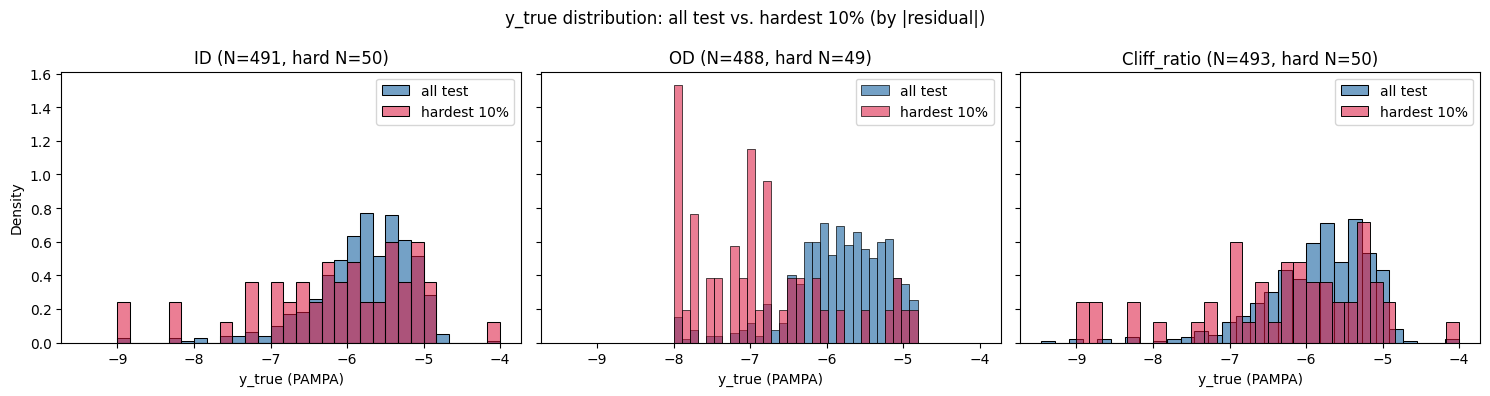

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharex=True, sharey=True)
for ax, (s, df) in zip(axes, frames.items()):
    thresh = df['abs_residual'].quantile(0.9)
    hard = df[df['abs_residual'] >= thresh]
    sns.histplot(df['y_true'], bins=30, stat='density', color='steelblue', ax=ax, label='all test')
    sns.histplot(hard['y_true'], bins=30, stat='density', color='crimson', alpha=0.55, ax=ax, label='hardest 10%')
    ax.set_title(f'{s} (N={len(df)}, hard N={len(hard)})')
    ax.set_xlabel('y_true (PAMPA)')
    ax.legend()
plt.suptitle('y_true distribution: all test vs. hardest 10% (by |residual|)')
plt.tight_layout(); plt.show()

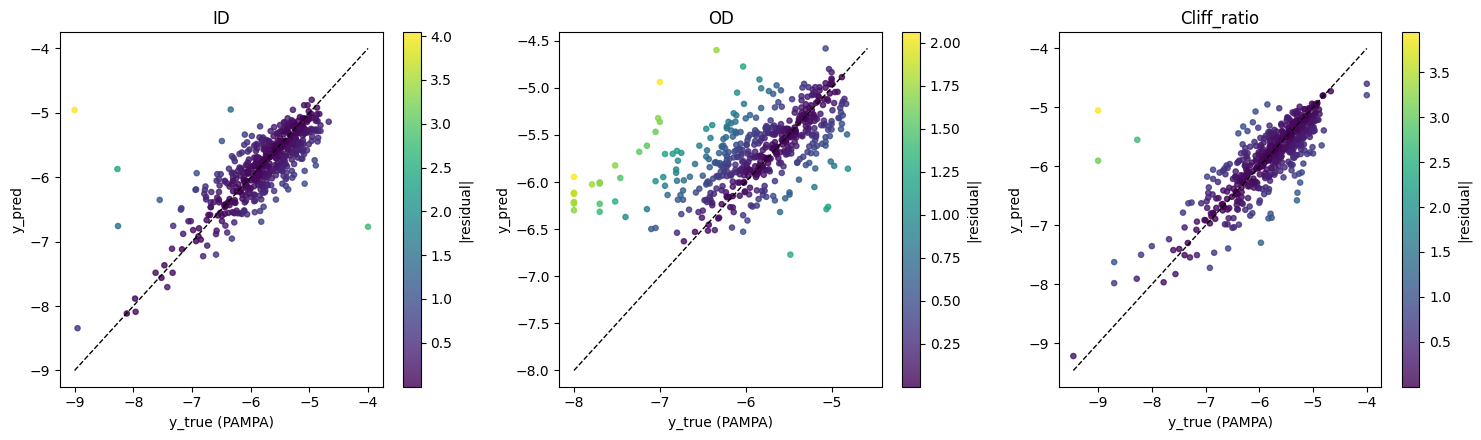

In [4]:
# Predicted vs. true scatter, coloured by |residual|
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, (s, df) in zip(axes, frames.items()):
    sc = ax.scatter(df['y_true'], df['y_pred'], c=df['abs_residual'], cmap='viridis', s=14, alpha=0.8)
    lo = min(df['y_true'].min(), df['y_pred'].min()); hi = max(df['y_true'].max(), df['y_pred'].max())
    ax.plot([lo, hi], [lo, hi], 'k--', linewidth=1)
    ax.set_xlabel('y_true (PAMPA)'); ax.set_ylabel('y_pred')
    ax.set_title(f'{s}')
    plt.colorbar(sc, ax=ax, label='|residual|')
plt.tight_layout(); plt.show()

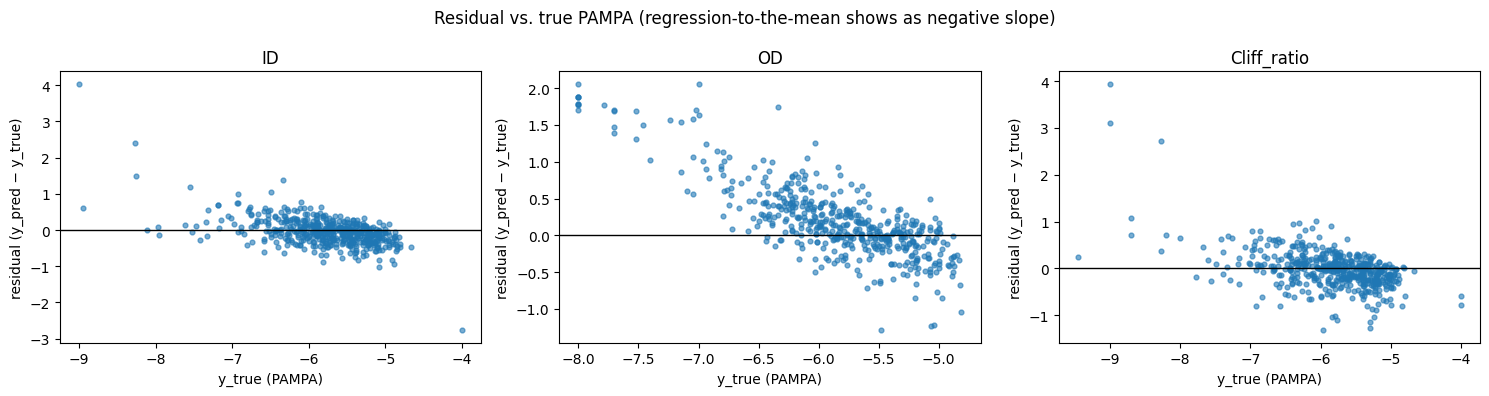

In [5]:
# Residual vs y_true: shows systematic over/under-prediction by target value
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (s, df) in zip(axes, frames.items()):
    ax.scatter(df['y_true'], df['residual'], s=12, alpha=0.6)
    ax.axhline(0, color='k', linewidth=1)
    ax.set_xlabel('y_true (PAMPA)'); ax.set_ylabel('residual (y_pred − y_true)')
    ax.set_title(f'{s}')
plt.suptitle('Residual vs. true PAMPA (regression-to-the-mean shows as negative slope)')
plt.tight_layout(); plt.show()

## 2. Molecular descriptors
For each descriptor present in the test CSV, compare the **hardest-10 % subset** against the **rest** using Welch's t-test (continuous) and report effect size (Cohen's d). Then visualise the top movers.

In [6]:
from scipy.stats import ttest_ind, spearmanr

NUMERIC_DESCS = [c for c in DESC_COLS if c not in ('SMILES','Sequence')]

def descriptor_stats(df, cols):
    thresh = df['abs_residual'].quantile(0.9)
    hard = df[df['abs_residual'] >= thresh]
    rest = df[df['abs_residual'] <  thresh]
    rows = []
    for c in cols:
        if c not in df.columns: continue
        a = pd.to_numeric(hard[c], errors='coerce').dropna()
        b = pd.to_numeric(rest[c], errors='coerce').dropna()
        if len(a) < 5 or len(b) < 5: continue
        t, p = ttest_ind(a, b, equal_var=False)
        # Cohen's d (pooled SD)
        sd = math.sqrt(((len(a)-1)*a.var() + (len(b)-1)*b.var()) / (len(a)+len(b)-2))
        d = (a.mean() - b.mean()) / sd if sd > 0 else 0.0
        # Spearman with |residual| across the full set
        x = pd.to_numeric(df[c], errors='coerce')
        m = ~x.isna()
        rho, prho = spearmanr(x[m], df.loc[m, 'abs_residual'])
        rows.append({'descriptor': c, 'hard_mean': a.mean(), 'rest_mean': b.mean(),
                     'cohen_d': d, 'welch_p': p,
                     'spearman_|res|': rho, 'spearman_p': prho})
    return pd.DataFrame(rows).sort_values('cohen_d', key=lambda s: s.abs(), ascending=False)

stats_by_split = {s: descriptor_stats(df, NUMERIC_DESCS) for s, df in frames.items()}
for s, st in stats_by_split.items():
    print(f'\n=== {s}: top descriptors separating hardest 10% from rest ===')
    display(st.head(10).style.format({'hard_mean':'{:.3f}','rest_mean':'{:.3f}','cohen_d':'{:.2f}',
                                       'welch_p':'{:.1e}','spearman_|res|':'{:.2f}','spearman_p':'{:.1e}'}))


=== ID: top descriptors separating hardest 10% from rest ===


,descriptor,hard_mean,rest_mean,cohen_d,welch_p,spearman_|res|,spearman_p
16,RingCount,3.640,3.955,-0.30,2.5e-02,-0.08,6.6e-02
12,NumHDonors,3.460,3.127,0.29,8.4e-02,0.08,8.5e-02
18,MolLogP,2.841,2.982,-0.19,2.4e-01,-0.12,6.0e-03
15,NumAromaticRings,0.940,1.150,-0.19,1.3e-01,-0.07,1.4e-01
8,MinPartialCharge,-0.398,-0.390,-0.16,3.2e-01,-0.02,6.5e-01
19,LabuteASA,362.714,368.457,-0.11,4.7e-01,-0.06,1.7e-01
6,qed,0.279,0.288,-0.11,4.7e-01,-0.02,7.4e-01
3,HeavyAtomMolWt,781.663,793.928,-0.11,4.8e-01,-0.06,1.7e-01
2,MolWt,854.280,866.527,-0.10,5.3e-01,-0.06,1.9e-01
4,ExactMolWt,853.705,865.937,-0.10,5.3e-01,-0.06,1.9e-01



=== OD: top descriptors separating hardest 10% from rest ===


,descriptor,hard_mean,rest_mean,cohen_d,welch_p,spearman_|res|,spearman_p
8,MinPartialCharge,-0.429,-0.351,-1.98,3.1e-08,-0.23,3.6e-07
18,MolLogP,1.853,3.121,-1.53,4.0e-06,-0.22,1.0e-06
12,NumHDonors,4.367,2.761,1.32,1.6e-06,0.27,1.6e-09
17,TPSA,172.941,155.317,1.12,8.0e-06,0.24,1.5e-07
14,NumRotatableBonds,7.816,8.784,-0.81,3.7e-04,-0.16,2.9e-04
19,LabuteASA,306.581,330.078,-0.74,3.7e-05,-0.16,3.4e-04
5,NumValenceElectrons,282.735,302.059,-0.73,6.3e-05,-0.16,4.3e-04
13,NumHAcceptors,6.898,6.467,0.70,3.7e-04,0.14,1.4e-03
2,MolWt,720.491,769.495,-0.68,8.1e-05,-0.15,1.1e-03
4,ExactMolWt,720.001,768.960,-0.68,8.1e-05,-0.15,1.1e-03



=== Cliff_ratio: top descriptors separating hardest 10% from rest ===


,descriptor,hard_mean,rest_mean,cohen_d,welch_p,spearman_|res|,spearman_p
18,MolLogP,2.508,2.922,-0.55,1.7e-04,-0.19,1.3e-05
12,NumHDonors,3.580,3.104,0.37,1.9e-02,0.13,4.2e-03
15,NumAromaticRings,0.860,1.248,-0.36,2.9e-03,-0.07,1.4e-01
16,RingCount,3.640,3.989,-0.33,7.9e-03,-0.02,7.0e-01
17,TPSA,189.676,183.515,0.15,3.4e-01,0.07,1.0e-01
19,LabuteASA,352.681,359.740,-0.14,3.7e-01,-0.08,7.8e-02
3,HeavyAtomMolWt,760.768,775.036,-0.13,4.2e-01,-0.07,1.0e-01
14,NumRotatableBonds,10.160,10.456,-0.12,4.5e-01,-0.11,1.4e-02
2,MolWt,831.126,845.327,-0.12,4.7e-01,-0.07,1.1e-01
4,ExactMolWt,830.568,844.751,-0.12,4.7e-01,-0.07,1.1e-01


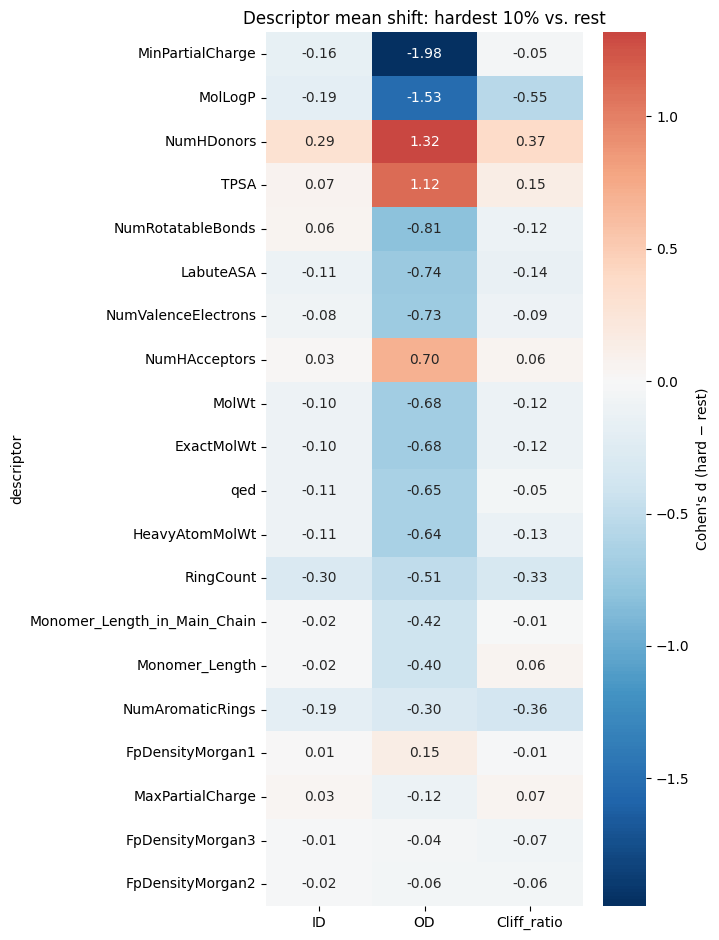

In [7]:
# Heatmap of Cohen's d (hard vs rest) per descriptor across splits — quickly read which feature differs
common = sorted(set.intersection(*[set(st['descriptor']) for st in stats_by_split.values()]))
mat = pd.DataFrame({s: stats_by_split[s].set_index('descriptor').loc[common, 'cohen_d']
                    for s in stats_by_split})
mat = mat.reindex(mat.abs().max(axis=1).sort_values(ascending=False).index).head(20)
plt.figure(figsize=(7, 0.4 * len(mat) + 1.5))
sns.heatmap(mat, cmap='RdBu_r', center=0, annot=True, fmt='.2f', cbar_kws={'label': "Cohen's d (hard − rest)"})
plt.title('Descriptor mean shift: hardest 10% vs. rest')
plt.tight_layout(); plt.show()

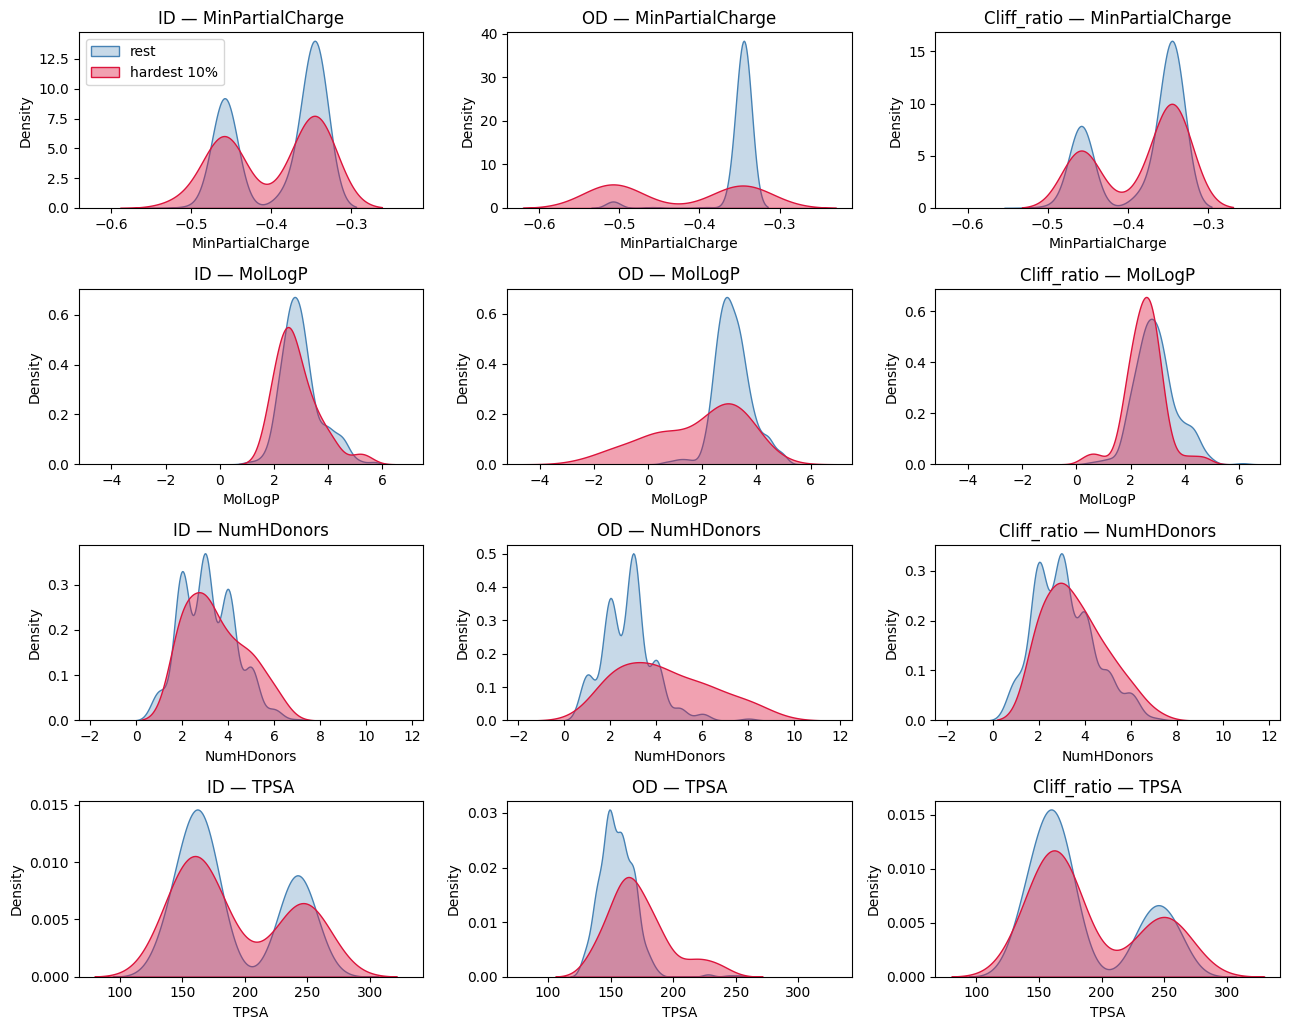

In [8]:
# Distribution plot for the top 4 movers in OD
top_in_od = stats_by_split['OD']['descriptor'].head(4).tolist()
fig, axes = plt.subplots(len(top_in_od), 3, figsize=(13, 2.6 * len(top_in_od)), sharex='row')
for i, desc in enumerate(top_in_od):
    for j, (s, df) in enumerate(frames.items()):
        ax = axes[i, j]
        if desc not in df.columns: continue
        thresh = df['abs_residual'].quantile(0.9)
        sns.kdeplot(pd.to_numeric(df.loc[df['abs_residual']  < thresh, desc], errors='coerce').dropna(),
                    ax=ax, color='steelblue', label='rest', fill=True, alpha=0.3)
        sns.kdeplot(pd.to_numeric(df.loc[df['abs_residual'] >= thresh, desc], errors='coerce').dropna(),
                    ax=ax, color='crimson', label='hardest 10%', fill=True, alpha=0.4)
        ax.set_title(f'{s} — {desc}')
        if i == 0 and j == 0: ax.legend()
plt.tight_layout(); plt.show()

## 3. Error pattern: over- vs. under-prediction
Hard samples can be skewed: model may be **systematically pessimistic** in one regime and optimistic in another.

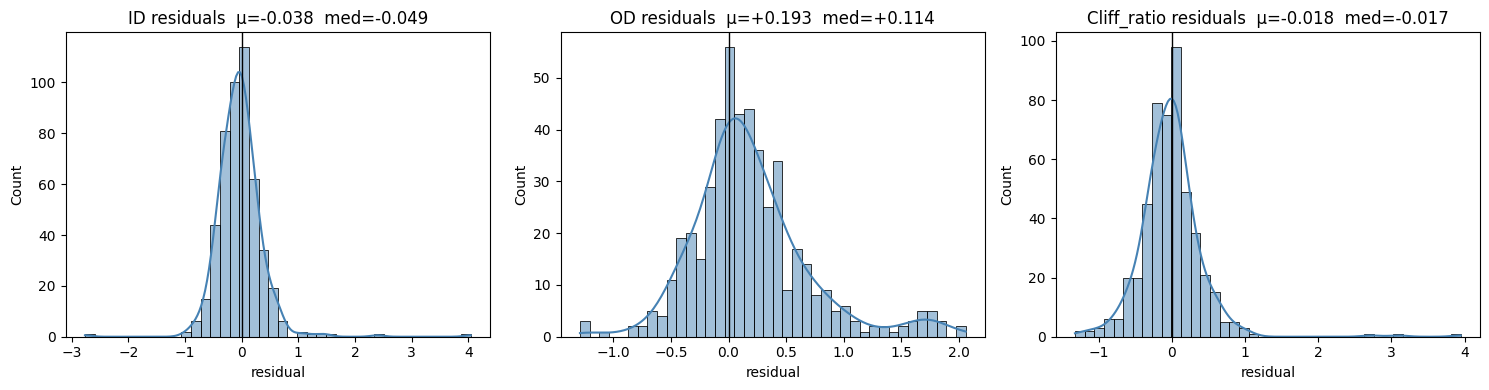

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (s, df) in zip(axes, frames.items()):
    sns.histplot(df['residual'], bins=40, ax=ax, kde=True, color='steelblue')
    ax.axvline(0, color='k', linewidth=1)
    ax.set_title(f'{s} residuals  μ={df["residual"].mean():+.3f}  med={df["residual"].median():+.3f}')
    ax.set_xlabel('residual')
plt.tight_layout(); plt.show()

In [10]:
# Hard samples table — top-15 by |residual| for each split
show_cols = ['CycPeptMPDB_ID','y_true','y_pred','residual','MolWt','MolLogP','TPSA','qed','Monomer_Length']
for s, df in frames.items():
    cols = [c for c in show_cols if c in df.columns]
    top = df.nlargest(15, 'abs_residual')[cols + ['abs_residual']]
    print(f'\n=== {s}: hardest 15 ===')
    display(top.style.format({'y_true':'{:.3f}','y_pred':'{:.3f}','residual':'{:+.3f}','abs_residual':'{:.3f}',
                              'MolWt':'{:.1f}','MolLogP':'{:.2f}','TPSA':'{:.1f}','qed':'{:.3f}'}))


=== ID: hardest 15 ===


,CycPeptMPDB_ID,y_true,y_pred,residual,MolWt,MolLogP,TPSA,qed,Monomer_Length,abs_residual
273,6036,-9.000,-4.956,+4.044,1030.4,2.95,235.5,0.214,10,4.044
10,4631,-4.000,-6.769,-2.769,766.0,2.15,177.3,0.314,7,2.769
201,1820,-8.270,-5.872,+2.398,815.0,4.09,166.7,0.305,6,2.398
487,1729,-8.260,-6.758,+1.502,803.0,4.04,157.9,0.288,6,1.502
476,2363,-6.340,-4.948,+1.392,727.0,3.72,139.4,0.377,6,1.392
22,6770,-7.550,-6.351,+1.199,1002.3,2.26,253.0,0.177,10,1.199
364,2958,-6.490,-5.437,+1.053,682.9,2.50,148.2,0.384,6,1.053
174,3325,-5.080,-6.100,-1.020,668.9,2.16,157.0,0.333,6,1.020
480,6818,-6.920,-5.936,+0.984,1016.3,2.60,244.2,0.207,10,0.984
428,5106,-4.890,-5.816,-0.926,808.1,3.23,159.8,0.368,7,0.926



=== OD: hardest 15 ===


,CycPeptMPDB_ID,y_true,y_pred,residual,MolWt,MolLogP,TPSA,qed,Monomer_Length,abs_residual
325,1060,-7.000,-4.939,+2.061,755.0,3.57,159.7,0.330,6,2.061
88,1106,-8.000,-5.946,+2.054,710.8,-0.78,217.7,0.183,6,2.054
143,1082,-8.000,-6.114,+1.886,648.8,0.30,186.0,0.260,6,1.886
175,1099,-8.000,-6.122,+1.878,636.8,0.06,194.8,0.223,6,1.878
223,1078,-8.000,-6.125,+1.875,648.8,0.30,186.0,0.260,6,1.875
399,1101,-8.000,-6.215,+1.785,665.7,-1.33,237.9,0.168,6,1.785
447,1094,-8.000,-6.215,+1.785,454.5,-2.29,157.0,0.323,6,1.785
318,1096,-8.000,-6.229,+1.771,674.8,0.79,177.2,0.301,6,1.771
162,4383,-7.790,-6.025,+1.765,882.1,3.73,159.8,0.273,7,1.765
455,2363,-6.340,-4.600,+1.740,727.0,3.72,139.4,0.377,6,1.740



=== Cliff_ratio: hardest 15 ===


,CycPeptMPDB_ID,y_true,y_pred,residual,MolWt,MolLogP,TPSA,qed,Monomer_Length,abs_residual
259,6036,-9.000,-5.053,+3.947,1030.4,2.95,235.5,0.214,10,3.947
66,6160,-9.000,-5.904,+3.096,1016.3,2.60,244.2,0.184,10,3.096
204,1820,-8.270,-5.549,+2.721,815.0,4.09,166.7,0.305,6,2.721
352,6165,-5.970,-7.295,-1.325,1016.3,2.60,244.2,0.184,10,1.325
38,4187,-5.300,-6.576,-1.276,780.0,2.49,168.5,0.365,7,1.276
205,5435,-5.290,-6.446,-1.156,766.0,2.15,177.3,0.314,7,1.156
26,4485,-5.770,-6.871,-1.101,766.0,2.15,177.3,0.314,7,1.101
339,6194,-8.700,-7.622,+1.078,988.3,1.92,261.8,0.137,10,1.078
426,3897,-5.830,-6.881,-1.051,766.0,2.15,177.3,0.314,7,1.051
335,3031,-5.240,-6.274,-1.034,654.9,1.82,165.8,0.287,6,1.034


## 4. Train-set neighbourhood (Tanimoto)
Hypothesis: OD failure is driven by test molecules that have **no close analog in train**. Compute max Tanimoto similarity of each test SMILES to the train set and correlate with |residual|.

This block is heavier — uses Morgan fingerprints from RDKit. Skip if RDKit isn't available.

ID: Spearman(max_Tanimoto_to_train, |residual|) = -0.041 (p=3.7e-01)


OD: Spearman(max_Tanimoto_to_train, |residual|) = -0.242 (p=6.3e-08)


Cliff_ratio: Spearman(max_Tanimoto_to_train, |residual|) = +0.103 (p=2.2e-02)


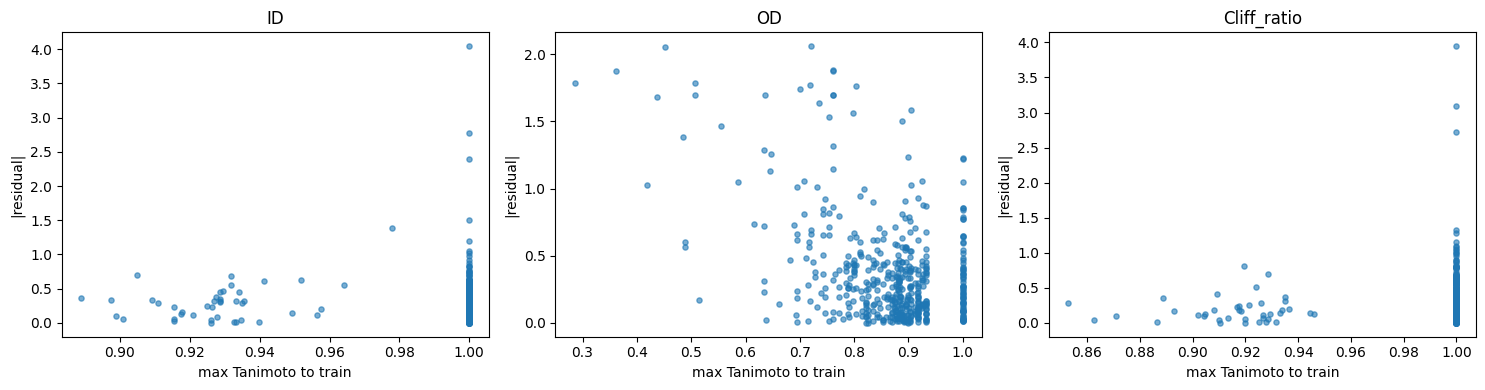

In [11]:
try:
    from rdkit import Chem
    from rdkit.Chem import AllChem, DataStructs

    def morgan_fps(smiles_list, radius=2, n_bits=2048):
        fps = []
        for s in smiles_list:
            try:
                m = Chem.MolFromSmiles(s)
                fps.append(AllChem.GetMorganFingerprintAsBitVect(m, radius, nBits=n_bits) if m else None)
            except Exception:
                fps.append(None)
        return fps

    def max_tanimoto_to_train(test_smi, train_smi):
        tr_fps = [f for f in morgan_fps(train_smi) if f is not None]
        out = []
        for f in morgan_fps(test_smi):
            if f is None: out.append(np.nan); continue
            sims = DataStructs.BulkTanimotoSimilarity(f, tr_fps)
            out.append(max(sims) if sims else np.nan)
        return np.array(out)

    for s, df in frames.items():
        if 'SMILES' not in df.columns: continue
        train_smi = pd.read_csv(DATA / f'{s}_train.csv')['SMILES'].tolist()
        df['max_tanimoto_train'] = max_tanimoto_to_train(df['SMILES'].tolist(), train_smi)
        rho, p = spearmanr(df['max_tanimoto_train'].fillna(0), df['abs_residual'])
        print(f'{s}: Spearman(max_Tanimoto_to_train, |residual|) = {rho:+.3f} (p={p:.1e})')

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for ax, (s, df) in zip(axes, frames.items()):
        if 'max_tanimoto_train' not in df.columns: continue
        ax.scatter(df['max_tanimoto_train'], df['abs_residual'], s=14, alpha=0.6)
        ax.set_xlabel('max Tanimoto to train'); ax.set_ylabel('|residual|')
        ax.set_title(f'{s}')
    plt.tight_layout(); plt.show()
except ModuleNotFoundError:
    print('rdkit not available in current kernel; skip')

## 5. ID vs OD: which samples slip when we switch splits?
Test sets of ID and OD overlap somewhat (same CycPeptMPDB_IDs appear in both 4D test partitions sometimes). For shared IDs, compare residuals.

shared test IDs between ID and OD: 36


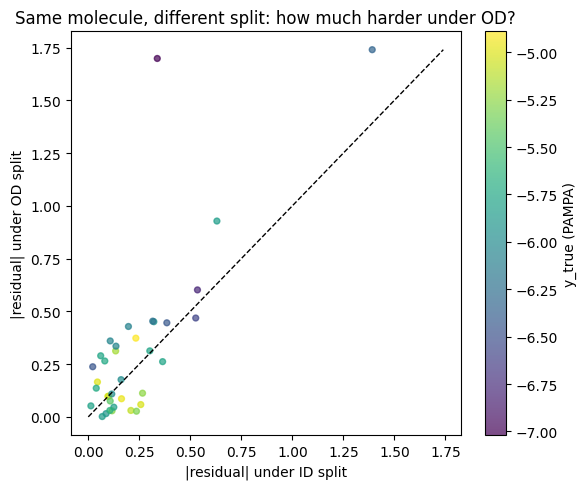

In [12]:
id_df = frames['ID'][['CycPeptMPDB_ID','residual','abs_residual','y_true']].rename(columns={'residual':'res_ID','abs_residual':'abs_ID'})
od_df = frames['OD'][['CycPeptMPDB_ID','residual','abs_residual']].rename(columns={'residual':'res_OD','abs_residual':'abs_OD'})
joined = id_df.merge(od_df, on='CycPeptMPDB_ID', how='inner')
print(f'shared test IDs between ID and OD: {len(joined)}')
if len(joined) > 0:
    fig, ax = plt.subplots(figsize=(6, 5))
    sc = ax.scatter(joined['abs_ID'], joined['abs_OD'], c=joined['y_true'], cmap='viridis', s=18, alpha=0.7)
    m = max(joined['abs_ID'].max(), joined['abs_OD'].max())
    ax.plot([0, m], [0, m], 'k--', lw=1)
    ax.set_xlabel('|residual| under ID split'); ax.set_ylabel('|residual| under OD split')
    plt.colorbar(sc, label='y_true (PAMPA)')
    plt.title('Same molecule, different split: how much harder under OD?')
    plt.tight_layout(); plt.show()

## Save a hard-sample report
Bundles hardest 10 % per split with descriptors + predictions to CSV for downstream inspection.

In [13]:
OUT = ROOT / 'eda' / 'hard_samples_mcp_id_od_cliffratio.csv'
parts = []
for s, df in frames.items():
    thresh = df['abs_residual'].quantile(0.9)
    h = df[df['abs_residual'] >= thresh].copy()
    h['split'] = s
    parts.append(h)
out = pd.concat(parts, ignore_index=True)
out.to_csv(OUT, index=False)
print(f'wrote {OUT}  rows={len(out)}')

wrote /ssd0/sohyun/cyclic_peptide/cyclic_peptide_permeability/eda/hard_samples_mcp_id_od_cliffratio.csv  rows=149
